# Turkish power sector Tutorial Part 4: Investigating Many Policy Scenarios

**Pre-requisites**
- You have the *MESSAGEix* framework installed and working
- You have run Turkish power sector baseline scenario (`turkey_revA.ipynb`) and solved it successfully
- You have completed the tutorial on introducing one policy scenario (`turkey_single_policy_revA.ipynb`) 

**Introduction**

In this notebook, we investigate a number of different scenarios.
This process is streamlined with the utility function `solve_modified()`, used in a Python `with:` statement:

```python
with solve_modified(base_scenario, new_name) as scen:
   # (`scen` is automatically cloned from `base_scenario` with name `new_name`)
   
   # Your code to modify `scen` <---

   # (`scen` is automatically committed with modifications, then solved)

# Your code to investigate the solution of `scen` <---
```

All of the cloning, committing, and solving actions are handled for you.
Your job is to concentrate on identifying and updating the scenario variables and then investigating the results.

You can, of course, get the `Scenario` as you have worked on previously as well.

## Setup and Helper Variables

In [1]:
# Load required packages 
import numpy as np
import pandas as pd

from matplotlib.pyplot import style
import matplotlib_inline

import ixmp as ix
import message_ix
from message_ix.reporting import Reporter
from message_ix.util.tutorial import prepare_plots, solve_modified
# from message_ix.testing import make_austria

# Appearance of plots
%matplotlib inline
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
style.use("ggplot")

/tmp/ipykernel_6124/1269771928.py:10: DeprecationWarning: Importing from 'message_ix.reporting' is deprecated and will fail in a future version. Use 'message_ix.report'.
  from message_ix.reporting import Reporter
Cannot redefine 'y' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)


In [2]:
# launch the IX modeling platform using the local default database                                                                                                                       
mp = ix.Platform(name="local")

2026-07-11 18:19:43,690  INFO at.ac.iiasa.ixmp.Platform:165 - Welcome to the IX modeling platform!
2026-07-11 18:19:43,700  INFO at.ac.iiasa.ixmp.Platform:166 -  connected to database 'jdbc:hsqldb:file:/home/ggungor/.local/share/ixmp/localdb/default' (user: ixmp)...


In [3]:
country = "Turkey"
horizon = range(2020, 2053, 5)

plants = [
    "lignite_ppl",
    "hardcoal_ppl", 
    "gas_ppl", 
    "oil_ppl", 
    "bio_ppl", 
    "hydro_ppl",
    "wind_ppl", 
    "geothermal",
    "solar_pv_ppl",
]

light_and_appliance = ["low_efficiency", "high_efficiency"]

In [4]:
# Create the baseline scenario and solve it
# base_scen = make_austria(mp, solve=True)
model = "Turkey energy model"
scen = "baseline"
base_scen = message_ix.Scenario(mp, model, scen)

# Create a reporter with tutorial plots
base_rep = Reporter.from_scenario(base_scen)
prepare_plots(base_rep)

<IPython.core.display.Javascript object>

<Axes: title={'center': 'Turkey Energy System Activity'}, xlabel='Year', ylabel='GWa'>

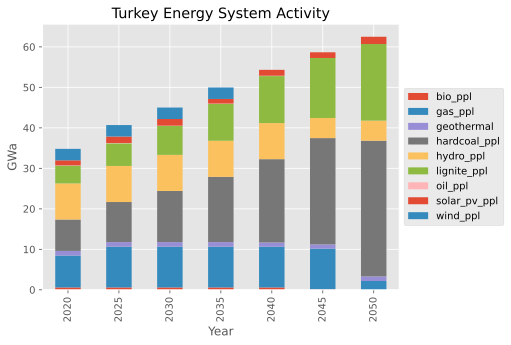

In [5]:
base_rep.set_filters(t=plants)
base_rep.get("plot activity")

In [6]:
emissions = {
    'lignite_ppl': ('CO2', 1.708),
    'hardcoal_ppl': ('CO2', 0.854), # units: tCO2/MWh
    'gas_ppl':  ('CO2', 0.339), # units: tCO2/MWh
    'oil_ppl':  ('CO2', 0.57),  # units: tCO2/MWh
}

# Wind Subsidies

Rerun the wind subsidy scenario using this framework.

In [7]:
# Percent subsidy by year
subsidies = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.5])

with solve_modified(base_scen, new_name="wind_subsidies") as wind_scen:
    # Load the investment cost data (cloned from `base_scen`) for wind_ppl
    data = wind_scen.par("inv_cost", filters=dict(technology="wind_ppl"))
    
    # Reduce the values according to the subsidy
    data["value"] = data["value"] * subsidies
    
    # Overwrite the values in `wind_scen` at the same indices
    wind_scen.add_par("inv_cost", data)
    
# Display the new costs
data

--- Warning: The GAMS version [51.3.0] differs from the API version [24.8.3].
--- Job MESSAGE_run.gms Start 07/11/26 18:22:27 51.3.0 38407a9b LEX-LEG x86 64bit/Linux
--- Applying:
    /home/ggungor/Downloads/gams51.3_linux_x64_64_sfx/gmsprmun.txt
--- GAMS Parameters defined
    Input /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/MESSAGE_run.gms
    ScrDir /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/225a/
    SysDir /home/ggungor/Downloads/gams51.3_linux_x64_64_sfx/
    LogOption 4
    LogFile /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/MESSAGE_run.log
    AppendLog 1
    --in /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/data/MsgData_Turkey_energy_model_wind_subsidies.gdx
    --out /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/output/MsgOutput_Turkey_energy_model_wind_subsidies.gdx
    --iter /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/mo

2026-07-11 18:22:28,470 ERROR at.ac.iiasa.ixmp.objects.Scenario:1691 - variable 'I' not found in gdx!
2026-07-11 18:22:28,472 ERROR at.ac.iiasa.ixmp.objects.Scenario:1691 - variable 'C' not found in gdx!


,node_loc,technology,year_vtg,value,unit
0,Turkey,wind_ppl,2020,0.0,USD/kW
1,Turkey,wind_ppl,2025,176.7,USD/kW
2,Turkey,wind_ppl,2030,353.4,USD/kW
3,Turkey,wind_ppl,2035,530.1,USD/kW
4,Turkey,wind_ppl,2040,706.8,USD/kW
5,Turkey,wind_ppl,2045,883.5,USD/kW
6,Turkey,wind_ppl,2050,883.5,USD/kW


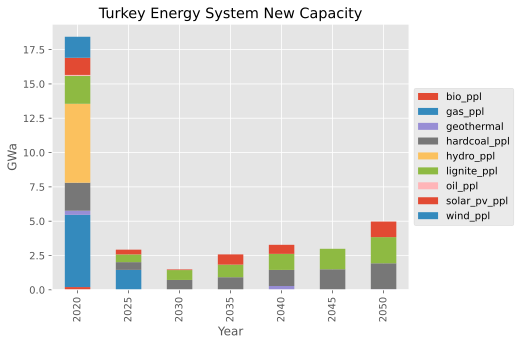

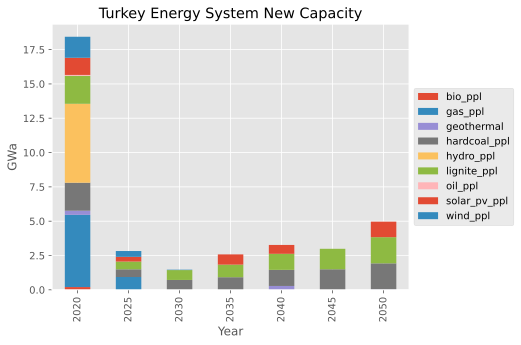

In [9]:
# Prepare a Reporter based on the solved scenario
wind_rep = Reporter.from_scenario(wind_scen)
prepare_plots(wind_rep)

# Run the same reporting on both the base and modified scenarios
for r in base_rep, wind_rep:
    r.set_filters(t=plants)
    r.get("plot new capacity")

# Demand-Side Learning

This model does not use `cfl`s in the baseline because they are too expensive. What happens if their cost reduces with time?

In [10]:
# Cost as a fraction of the baseline cost, due to learning
learning = np.array([1.0, 0.8, 0.6, 0.4, 0.2, 0.1, 0.05])

with solve_modified(base_scen, new_name="cheap_cfls") as cfl_scen:
    # Load the investment cost data (cloned from `base_scen`) for cfl
    data = cfl_scen.par("inv_cost", filters=dict(technology="high_efficiency"))
    
    # Reduce the values according to the learning curve
    data["value"] = data["value"] * learning
    
    # Overwrite the values in `cfl_scen` at the same indices
    cfl_scen.add_par("inv_cost", data)

# Display the new costs
data

--- Warning: The GAMS version [51.3.0] differs from the API version [24.8.3].
--- Job MESSAGE_run.gms Start 07/11/26 18:24:33 51.3.0 38407a9b LEX-LEG x86 64bit/Linux
--- Applying:
    /home/ggungor/Downloads/gams51.3_linux_x64_64_sfx/gmsprmun.txt
--- GAMS Parameters defined
    Input /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/MESSAGE_run.gms
    ScrDir /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/225a/
    SysDir /home/ggungor/Downloads/gams51.3_linux_x64_64_sfx/
    LogOption 4
    LogFile /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/MESSAGE_run.log
    AppendLog 1
    --in /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/data/MsgData_Turkey_energy_model_cheap_cfls.gdx
    --out /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/output/MsgOutput_Turkey_energy_model_cheap_cfls.gdx
    --iter /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/outp

2026-07-11 18:24:34,112 ERROR at.ac.iiasa.ixmp.objects.Scenario:1691 - variable 'I' not found in gdx!
2026-07-11 18:24:34,114 ERROR at.ac.iiasa.ixmp.objects.Scenario:1691 - variable 'C' not found in gdx!


,node_loc,technology,year_vtg,value,unit
0,Turkey,high_efficiency,2020,900.0,USD/kW
1,Turkey,high_efficiency,2025,720.0,USD/kW
2,Turkey,high_efficiency,2030,540.0,USD/kW
3,Turkey,high_efficiency,2035,360.0,USD/kW
4,Turkey,high_efficiency,2040,180.0,USD/kW
5,Turkey,high_efficiency,2045,90.0,USD/kW
6,Turkey,high_efficiency,2050,45.0,USD/kW


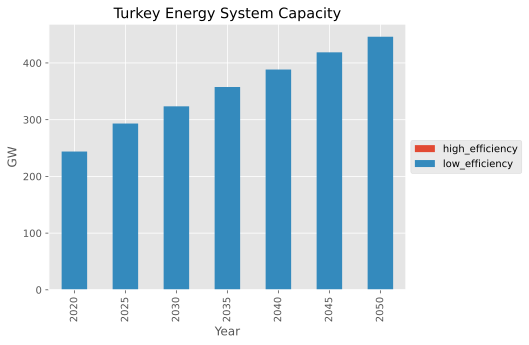

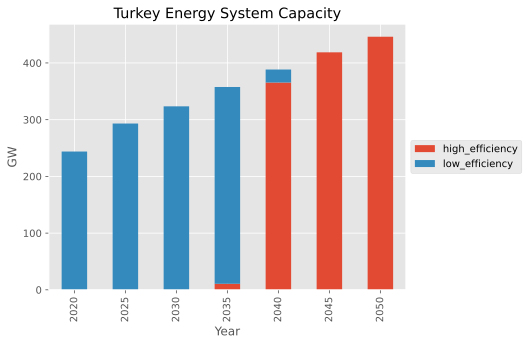

In [11]:
# Prepare a Reporter based on the solved scenario
cfl_rep = Reporter.from_scenario(cfl_scen)
prepare_plots(cfl_rep)

# Run the same reporting on both the base and modified scenarios
for r in base_rep, cfl_rep:
    r.set_filters(t=light_and_appliance)
    r.get("plot capacity")

# Exercise: Economic Assumptions

What is the effect of assuming a different interest rate? What if it is higher than the baseline? Lower? How does this affect prices?

In [12]:
# Show the baseline interest rate
base_scen.par('interestrate')

,year,value,unit
0,2020,0.1,-
1,2025,0.1,-
2,2030,0.1,-
3,2035,0.1,-
4,2040,0.1,-
5,2045,0.1,-
6,2050,0.1,-


In [13]:
# Uncomment and complete the following code where "TODO" appears
# with solve_modified(base_scen, new_name="TODO") as econ_scen:
#    # TODO modify the interest rate to a different value

# Cost as a fraction of the baseline cost, due to learning
economy = np.array([1.0, 0.8, 0.6, 0.4, 0.2, 0.1, 0.1])

with solve_modified(base_scen, new_name="economy") as econ_scen:
    # Load the investment cost data (cloned from `base_scen`) for cfl
    data = econ_scen.par("interestrate")
    
    # Reduce the values according to the learning curve
    data["value"] = data["value"] * economy
    
    # Overwrite the values in `cfl_scen` at the same indices
    econ_scen.add_par("interestrate", data)

# Display the new costs
data

--- Warning: The GAMS version [51.3.0] differs from the API version [24.8.3].
--- Job MESSAGE_run.gms Start 07/11/26 18:25:47 51.3.0 38407a9b LEX-LEG x86 64bit/Linux
--- Applying:
    /home/ggungor/Downloads/gams51.3_linux_x64_64_sfx/gmsprmun.txt
--- GAMS Parameters defined
    Input /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/MESSAGE_run.gms
    ScrDir /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/225a/
    SysDir /home/ggungor/Downloads/gams51.3_linux_x64_64_sfx/
    LogOption 4
    LogFile /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/MESSAGE_run.log
    AppendLog 1
    --in /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/data/MsgData_Turkey_energy_model_economy.gdx
    --out /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/output/MsgOutput_Turkey_energy_model_economy.gdx
    --iter /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/output/Msg

2026-07-11 18:25:48,161 ERROR at.ac.iiasa.ixmp.objects.Scenario:1691 - variable 'I' not found in gdx!
2026-07-11 18:25:48,161 ERROR at.ac.iiasa.ixmp.objects.Scenario:1691 - variable 'C' not found in gdx!


,year,value,unit
0,2020,0.10,-
1,2025,0.08,-
2,2030,0.06,-
3,2035,0.04,-
4,2040,0.02,-
5,2045,0.01,-
6,2050,0.01,-


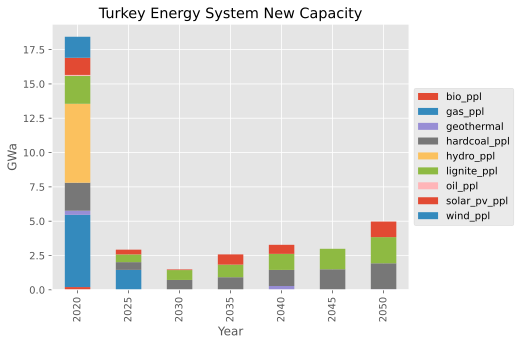

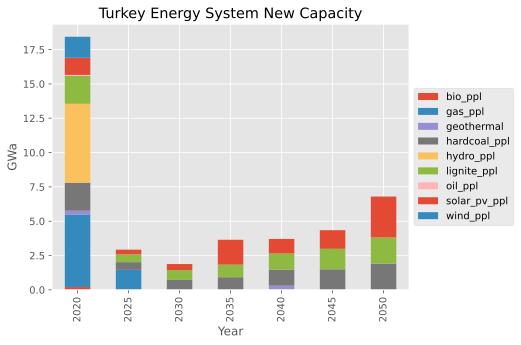

In [14]:
# TODO based on the examples above, plot (a) new capacity and (b) prices
# Prepare a Reporter based on the solved scenario
econ_rep = Reporter.from_scenario(econ_scen)
prepare_plots(econ_rep)

# Run the same reporting on both the base and modified scenarios
for r in base_rep, econ_rep:
    r.set_filters(t=plants)
    r.get("plot new capacity")

In [15]:
### Reporting emissions

In [16]:
from message_ix import Reporter

econ_rep.set_filters(t=plants)
emissions_list = econ_rep.get("emi")
emissions_list

nl      t        yv    ya    m         e    h   
Turkey  gas_ppl  2020  2020  standard  CO2  year    23.42151
                       2025  standard  CO2  year    23.42151
                       2030  standard  CO2  year    23.42151
                       2035  standard  CO2  year    23.42151
                       2040  standard  CO2  year    23.42151
                                                      ...   
        oil_ppl  2040  2045  standard  CO2  year     0.00000
                       2050  standard  CO2  year     0.00000
                 2045  2045  standard  CO2  year     0.00000
                       2050  standard  CO2  year     0.00000
                 2050  2050  standard  CO2  year     0.00000
Length: 110, dtype: float64, units: tCO2 / kWa

In [17]:
print(econ_rep.get("EMISS"))

n       e    type_tec  y   
World   CO2  all       2020    147.324000
                       2025    187.923129
                       2030    231.471269
                       2035    287.050957
                       2040    357.986289
                       2045    448.519744
                       2050    540.243135
Turkey  CO2  all       2020    147.324000
                       2025    187.923129
                       2030    231.471269
                       2035    287.050957
                       2040    357.986289
                       2045    448.519744
                       2050    540.243135
Name: EMISS, dtype: float64, units: dimensionless


# Exercise: Carbon Tax

What effect does a carbon tax have on the system? What if it is phased in over time? What is the effect on energy prices?

Hints:

- Which emissions parameters are available from `scenario.par_list()`?
- Find out which fields are required using `scenario.idx_names(par_name)`
- Carbon taxes are normally provided in units of USD/tCO2
- A normal proposed carbon tax is ~30 USD/tCO2

In [18]:
# Print the names of all parameters that contain "emission"
[name for name in base_scen.par_list() if "emission" in name]

['bound_emission',
 'emission_factor',
 'emission_scaling',
 'historical_emission',
 'land_emission',
 'tax_emission']

In [19]:
# Print the index names for one of these
base_scen.idx_names("tax_emission")

['node', 'type_emission', 'type_tec', 'type_year']

In [20]:
taxes = pd.DataFrame({
    "node": country,
    "type_emission": "GHGs",
    "type_year": horizon,
    "type_tec": "all",
    "value": np.array([0.0, 50.0, 100.0, 150.0, 200.0, 250.0, 300.0]),
    "unit": 'USD/tCO2', 
})

with solve_modified(base_scen, new_name="carbon_tax") as ctax_scen:
    ctax_scen.add_par('tax_emission', taxes)

--- Warning: The GAMS version [51.3.0] differs from the API version [24.8.3].
--- Job MESSAGE_run.gms Start 07/11/26 18:27:14 51.3.0 38407a9b LEX-LEG x86 64bit/Linux
--- Applying:
    /home/ggungor/Downloads/gams51.3_linux_x64_64_sfx/gmsprmun.txt
--- GAMS Parameters defined
    Input /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/MESSAGE_run.gms
    ScrDir /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/225a/
    SysDir /home/ggungor/Downloads/gams51.3_linux_x64_64_sfx/
    LogOption 4
    LogFile /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/MESSAGE_run.log
    AppendLog 1
    --in /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/data/MsgData_Turkey_energy_model_carbon_tax.gdx
    --out /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/output/MsgOutput_Turkey_energy_model_carbon_tax.gdx
    --iter /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/outp

2026-07-11 18:27:14,760 ERROR at.ac.iiasa.ixmp.objects.Scenario:1691 - variable 'I' not found in gdx!
2026-07-11 18:27:14,760 ERROR at.ac.iiasa.ixmp.objects.Scenario:1691 - variable 'C' not found in gdx!


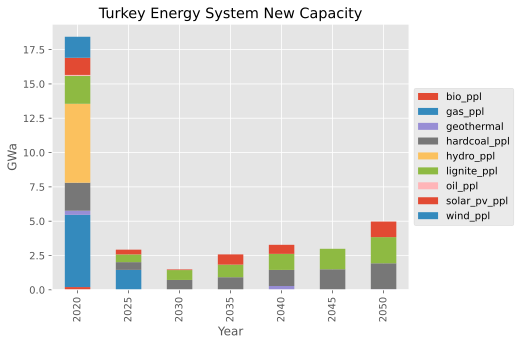

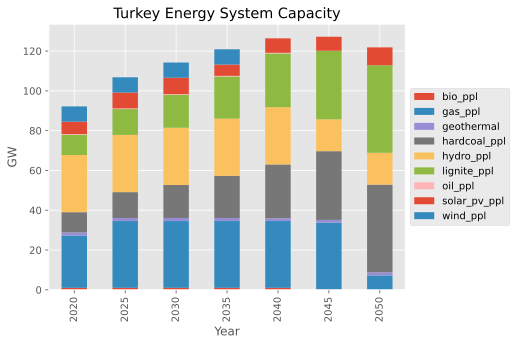

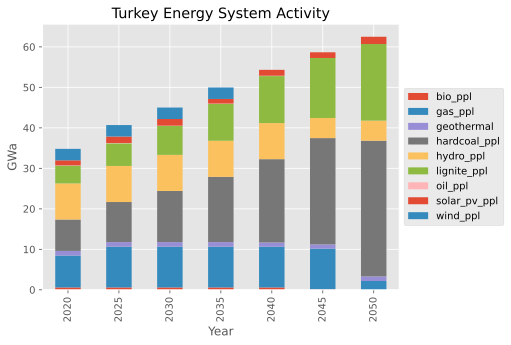

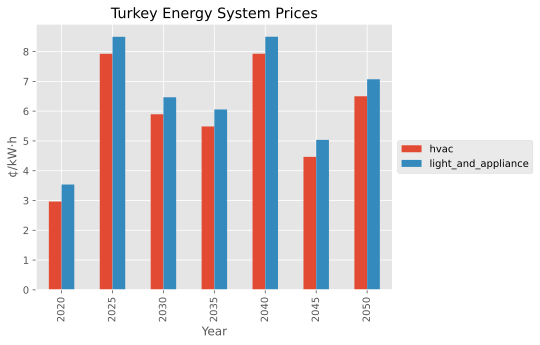

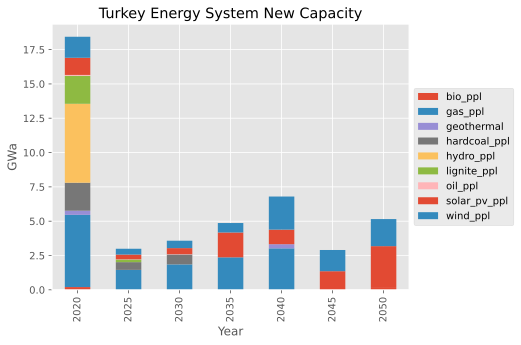

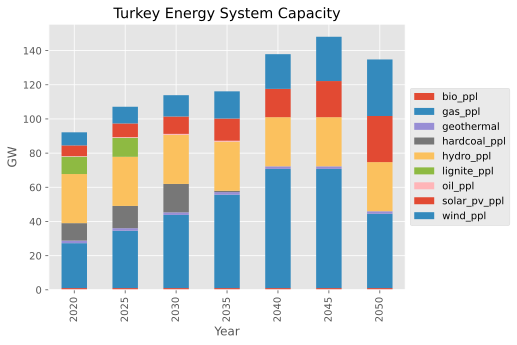

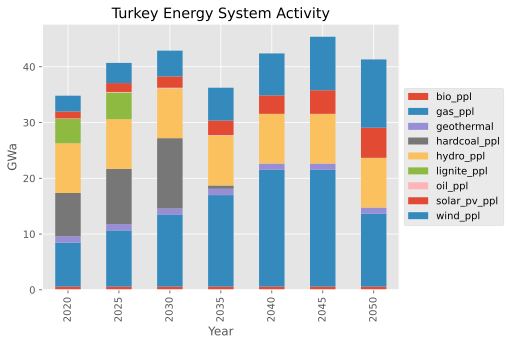

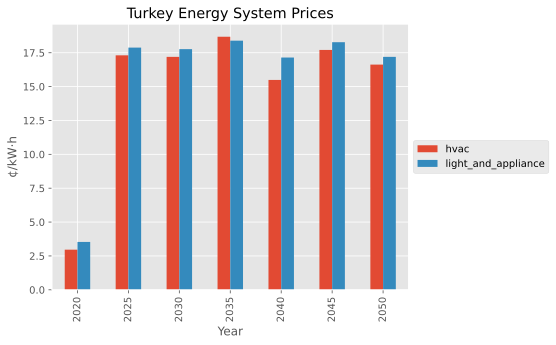

In [21]:
# Prepare a Reporter based on the solved scenario
ctax_rep = Reporter.from_scenario(ctax_scen)
prepare_plots(ctax_rep)

# Run the same reporting on both the base and modified scenarios
for r in base_rep, ctax_rep:
    r.set_filters(t=plants, c=None)
    r.get("plot new capacity")
    r.get("plot capacity")
    r.get("plot activity")
    r.set_filters(t=None, c=["hvac", "light_and_appliance"])
    r.get("plot prices")

In [22]:
print(ctax_rep.get("EMISS"))

n       e    type_tec  y   
World   CO2  all       2020    147.324000
                       2025    176.007434
                       2030    133.282524
                       2035     53.794878
                       2040     62.144239
                       2045     62.144239
                       2050     38.722729
Turkey  CO2  all       2020    147.324000
                       2025    176.007434
                       2030    133.282524
                       2035     53.794878
                       2040     62.144239
                       2045     62.144239
                       2050     38.722729
Name: EMISS, dtype: float64, units: dimensionless


In [32]:
emission = list(ctax_rep.get("EMISS").head(7))

# Exercise: Emissions constraint

In [23]:
# Print the index names for one of these
base_scen.idx_names("bound_emission")

['node', 'type_emission', 'type_tec', 'type_year']

In [33]:
bounds = pd.DataFrame({
    "node": country,
    "type_emission": "GHGs",
    "type_year": horizon,
    "type_tec": "all",
    "value": np.array(emission),
    "unit": 'tCO2', 
})

with solve_modified(base_scen, new_name="emissions_constraint") as emissions_scen:
    emissions_scen.add_par('bound_emission', bounds)

--- Warning: The GAMS version [51.3.0] differs from the API version [24.8.3].
--- Job MESSAGE_run.gms Start 07/11/26 18:33:01 51.3.0 38407a9b LEX-LEG x86 64bit/Linux
--- Applying:
    /home/ggungor/Downloads/gams51.3_linux_x64_64_sfx/gmsprmun.txt
--- GAMS Parameters defined
    Input /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/MESSAGE_run.gms
    ScrDir /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/225a/
    SysDir /home/ggungor/Downloads/gams51.3_linux_x64_64_sfx/
    LogOption 4
    LogFile /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/MESSAGE_run.log
    AppendLog 1
    --in /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/data/MsgData_Turkey_energy_model_emissions_constraint.gdx
    --out /home/ggungor/miniconda3/lib/python3.12/site-packages/message_ix/model/output/MsgOutput_Turkey_energy_model_emissions_constraint.gdx
    --iter /home/ggungor/miniconda3/lib/python3.12/site-packages/m

2026-07-11 18:33:01,512 ERROR at.ac.iiasa.ixmp.objects.Scenario:1691 - variable 'I' not found in gdx!
2026-07-11 18:33:01,512 ERROR at.ac.iiasa.ixmp.objects.Scenario:1691 - variable 'C' not found in gdx!


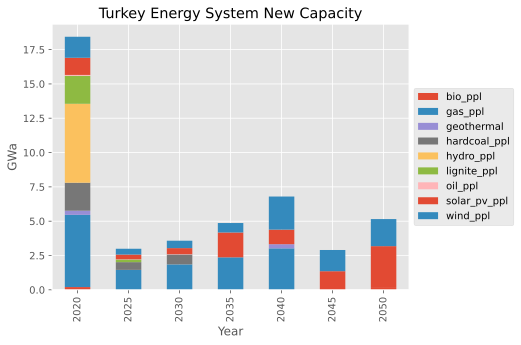

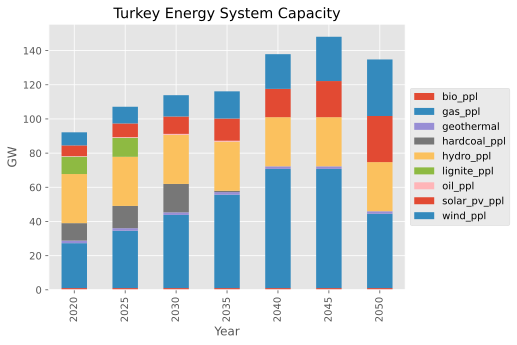

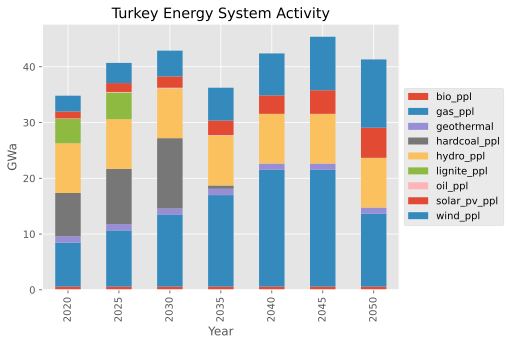

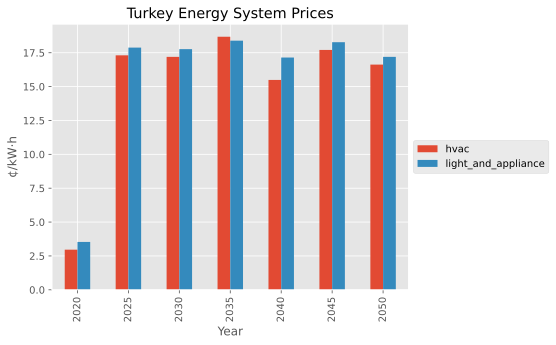

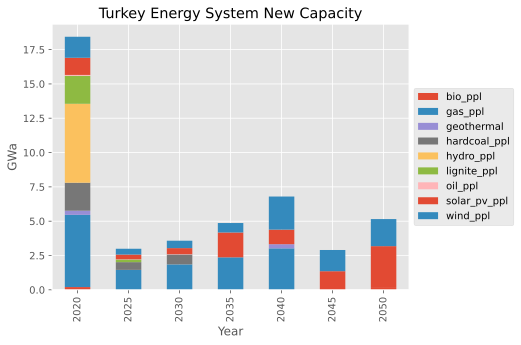

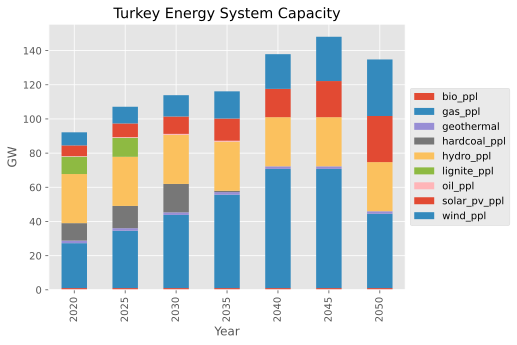

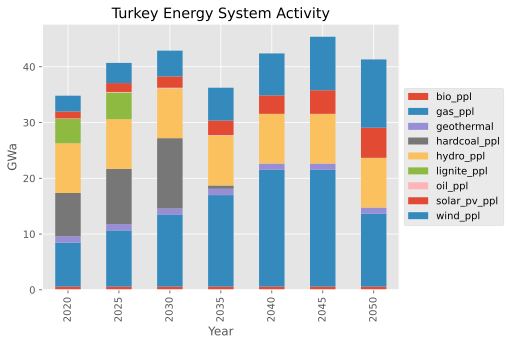

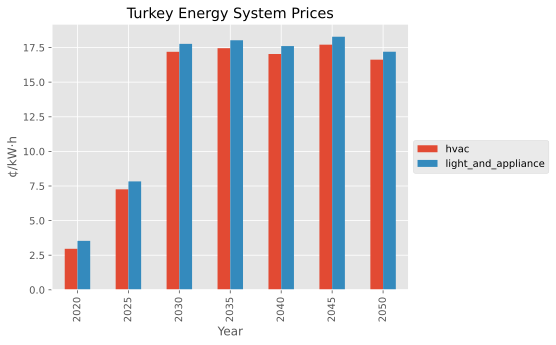

In [34]:
# Prepare a Reporter based on the solved scenario
emissions_rep = Reporter.from_scenario(emissions_scen)
prepare_plots(emissions_rep)

# Run the same reporting on both the base and modified scenarios
for r in ctax_rep, emissions_rep:
    r.set_filters(t=plants, c=None)
    r.get("plot new capacity")
    r.get("plot capacity")
    r.get("plot activity")
    r.set_filters(t=None, c=["hvac", "light_and_appliance"])
    r.get("plot prices")

In [35]:
mp.close_db()